## 注意力提示

### 查询、键和值

自主性的与非自主性的注意力提示解释了人类的注意力的方式， 下面来看看如何通过这两种注意力提示， 用神经网络来设计注意力机制的框架，

首先，考虑一个相对简单的状况， 即只使用非自主性提示。 要想将选择偏向于感官输入， 则可以简单地使用参数化的全连接层， 甚至是非参数化的最大汇聚层或平均汇聚层。

因此，“是否包含自主性提示”将注意力机制与全连接层或汇聚层区别开来。 在注意力机制的背景下，自主性提示被称为查询（query）。 给定任何查询，注意力机制通过注意力汇聚（attention pooling） 将选择引导至感官输入（sensory inputs，例如中间特征表示）。 在注意力机制中，这些感官输入被称为值（value）。 更通俗的解释，每个值都与一个键（key）配对， 这可以想象为感官输入的非自主提示。如图所示，可以通过设计注意力汇聚的方式， 便于给定的查询（自主性提示）与键（非自主性提示）进行匹配， 这将引导得出最匹配的值（感官输入）。

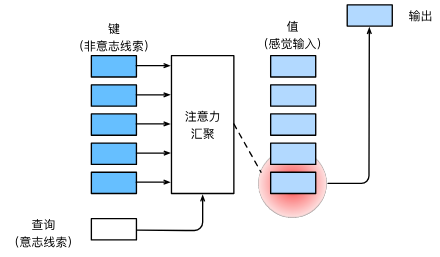

 因此这个框架下的模型将成为本章的中心。 然而，注意力机制的设计有许多替代方案。 例如可以设计一个不可微的注意力模型， 该模型可以使用强化学习方法 (Mnih et al., 2014)进行训练。

 ### 注意力的可视化

 平均汇聚层可以被视为输入的加权平均值， 其中各输入的权重是一样的。 实际上，注意力汇聚得到的是加权平均的总和值， 其中权重是在给定的查询和不同的键之间计算得出的。为了可视化注意力权重，需要定义一个show_heatmaps函数。 其输入matrices的形状是 （要显示的行数，要显示的列数，查询的数目，键的数目）。下面使用一个简单的例子进行演示。 在本例子中，仅当查询和键相同时，注意力权重为1，否则为0。

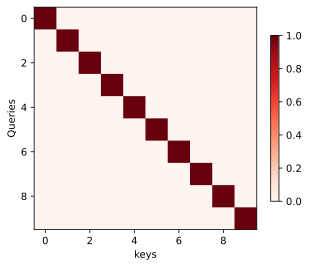

In [5]:
import torch
from d2l import torch as d2l

def show_heatmaps(matrices,xlabel,ylabel,titles=None,figsize=(5,5),cmap='Reds'):
    """显示矩阵热图"""
    d2l.use_svg_display()
    num_rows,num_cols = matrices.shape[0],matrices.shape[1]
    # 默认情况下，当子图网格仅包含一行或一列（即实际上相当于单个子图时），subplots 函数会返回单个 Axes 对象而非一维 numpy 数组。
    # 设置 squeeze=False 强制函数始终返回二维 numpy 数组形式的 Axes 对象
    fig,axes = d2l.plt.subplots(num_rows,num_cols,figsize=figsize, # sharex and sharey 表示此选项使得同一行内的所有子图共用相同的 x，y 轴 
                                sharex=True,sharey=True,squeeze=False)
    for i,(row_axes,row_matrices) in enumerate(zip(axes,matrices)):
        for j,(ax,matrix) in enumerate(zip(row_axes,row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(),cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm,ax=axes,shrink=0.6)
attention_weights = torch.eye(10).reshape((1,1,10,10))
show_heatmaps(attention_weights,xlabel='keys',ylabel='Queries')

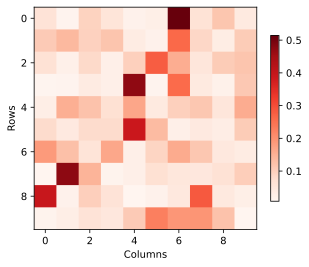

In [8]:
# 随机生成一个10x10矩阵并使用softmax运算来确保每行都是有效的概率分布，然后可视化输出注意力权重。
from torch.nn import functional as F
X = torch.randn((10,10))
X = F.softmax(X,dim=1)
X = X.reshape((1,1,10,10))
show_heatmaps(X,xlabel='Columns',ylabel='Rows')

## 总结
人类的注意力是有限的、有价值和稀缺的资源。

受试者使用非自主性和自主性提示有选择性地引导注意力。前者基于突出性，后者则依赖于意识。

注意力机制与全连接层或者汇聚层的区别源于增加的自主提示。

由于包含了自主性提示，注意力机制与全连接的层或汇聚层不同。

注意力机制通过注意力汇聚使选择偏向于值（感官输入），其中包含查询（自主性提示）和键（非自主性提示）。键和值是成对的。

可视化查询和键之间的注意力权重是可行的